In [2]:
!pip install nba_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 6.1 MB/s eta 0:00:00



  SPURS WITH / WITHOUT WEMBANYAMA — FULL ANALYSIS
  Season: 2025-26

[STEP 1] Fetching data...

  [1/4] Wembanyama game log...
         → 64 games with Wemby
  [2/4] Spurs team game log...
         → 82 total games
  [3/4] League team standings for opponent quality...
         → 30 teams, columns: ['TEAM_ID', 'TEAM_NAME', 'W_PCT', 'NET_RATING']
  [4/4] Fetching 29 opponent game logs for OPP_PTS...
         ✓ DAL  (82 games)
         ✓ NOP  (82 games)
         ✓ BKN  (82 games)
         ✓ TOR  (82 games)
         ✓ MIA  (82 games)
         ✓ PHX  (82 games)
         ✓ LAL  (82 games)
         ✓ HOU  (82 games)
         ✓ CHI  (82 games)
         ✓ GSW  (82 games)
         ✓ SAC  (82 games)
         ✓ MEM  (82 games)
         ✓ ATL  (82 games)
         ✓ POR  (82 games)
         ✓ DEN  (82 games)
         ✓ MIN  (82 games)
         ✓ ORL  (82 games)
         ✓ CLE  (82 games)
         ✓ OKC  (82 games)
         ✓ WAS  (82 games)
         ✓ UTA  (82 games)
         ✓ NYK  (82 games)
    

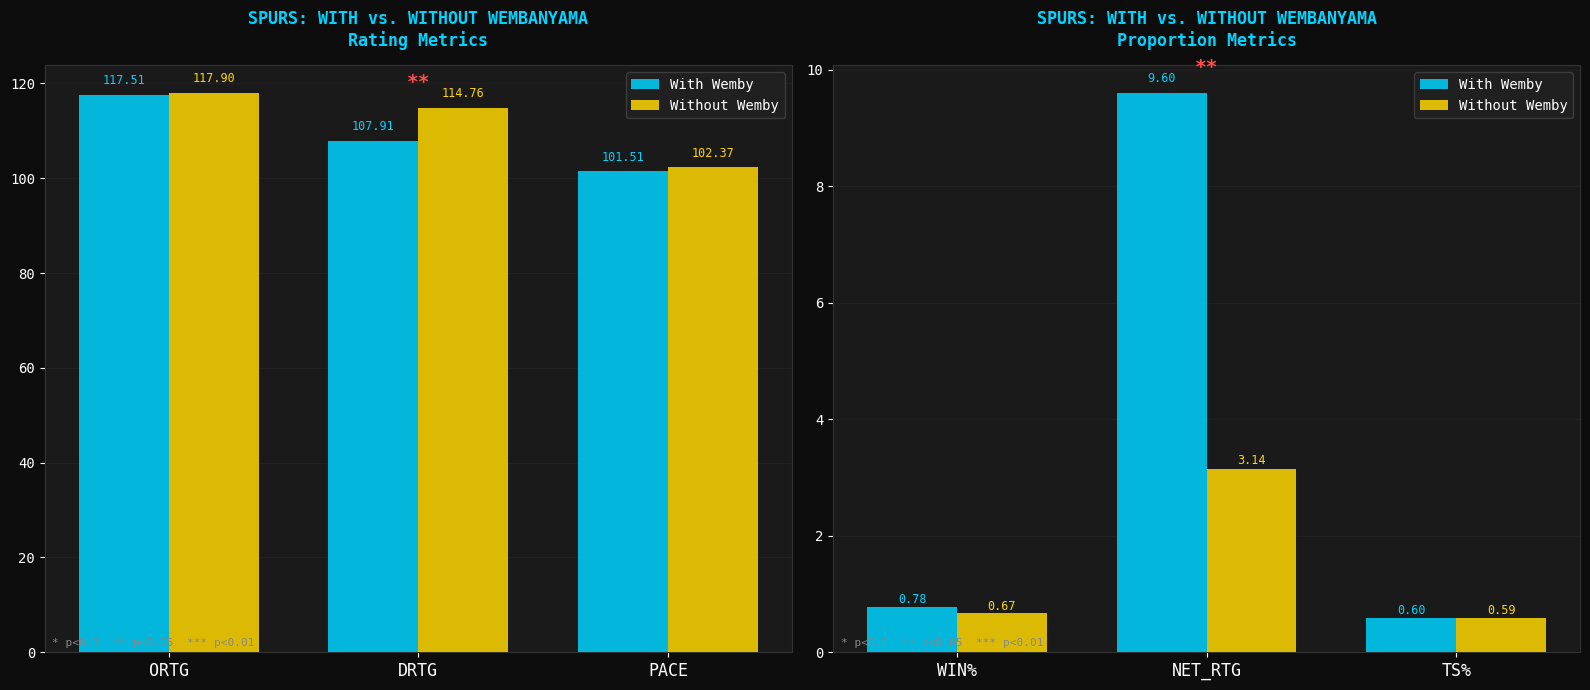

  Saved → fig_1_split_comparison.png
  Saved CSV → fig_2_drtg_timeline.csv


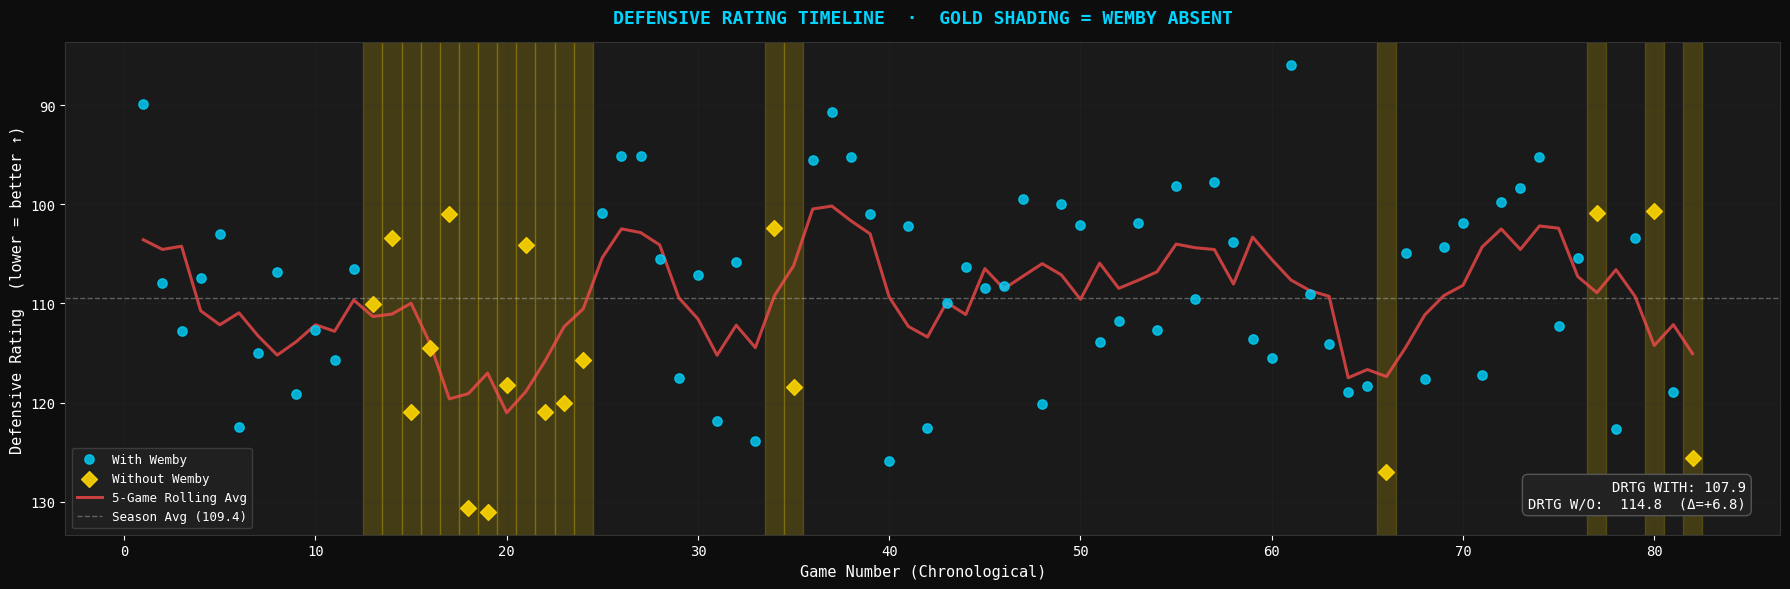

  Saved → fig_2_drtg_timeline.png
  Saved CSV → fig_3_opp_quality_scatter.csv


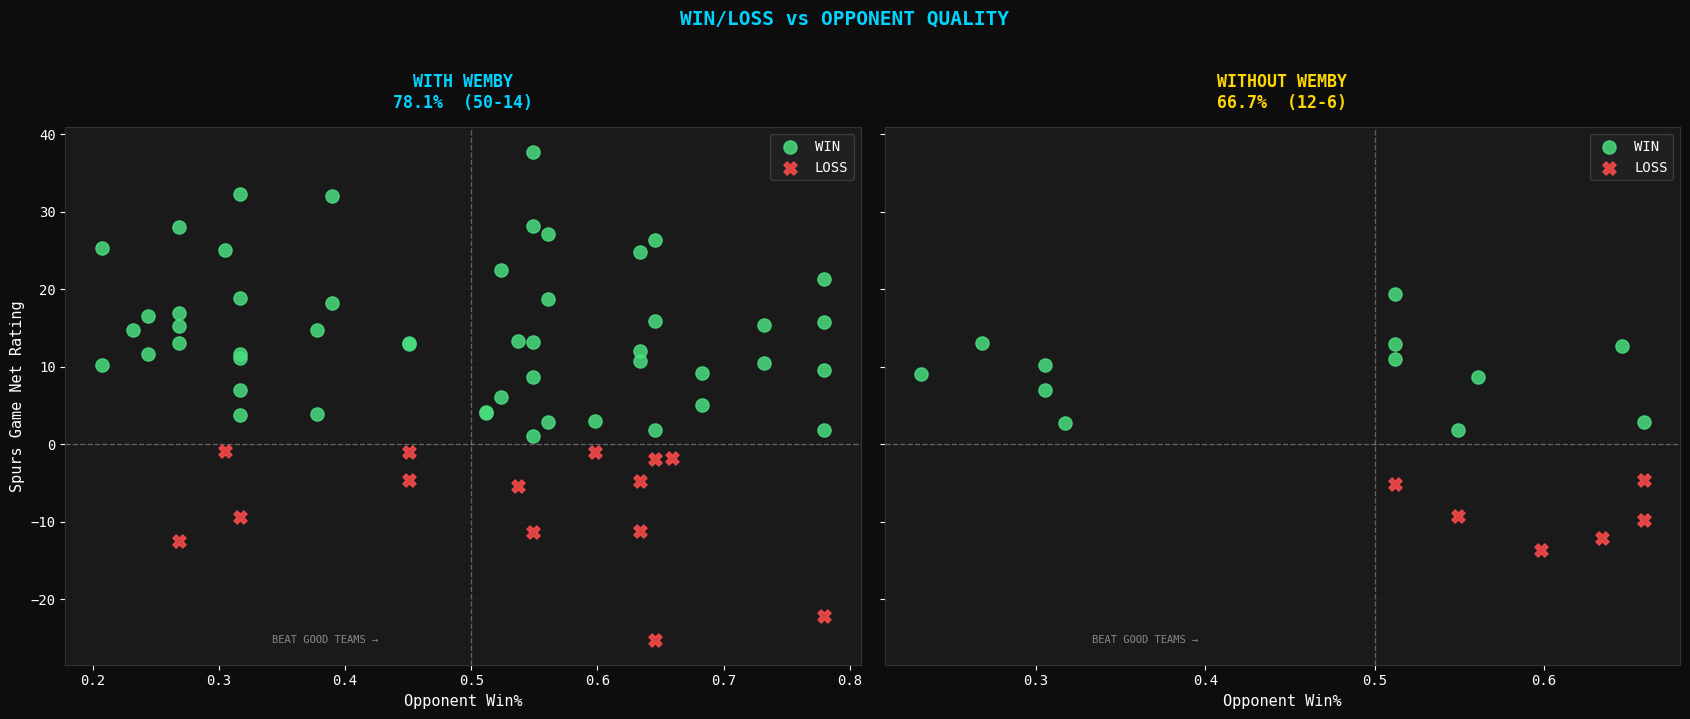

  Saved → fig_3_opp_quality_scatter.png
  Saved CSV → fig_4_delta_lollipop.csv


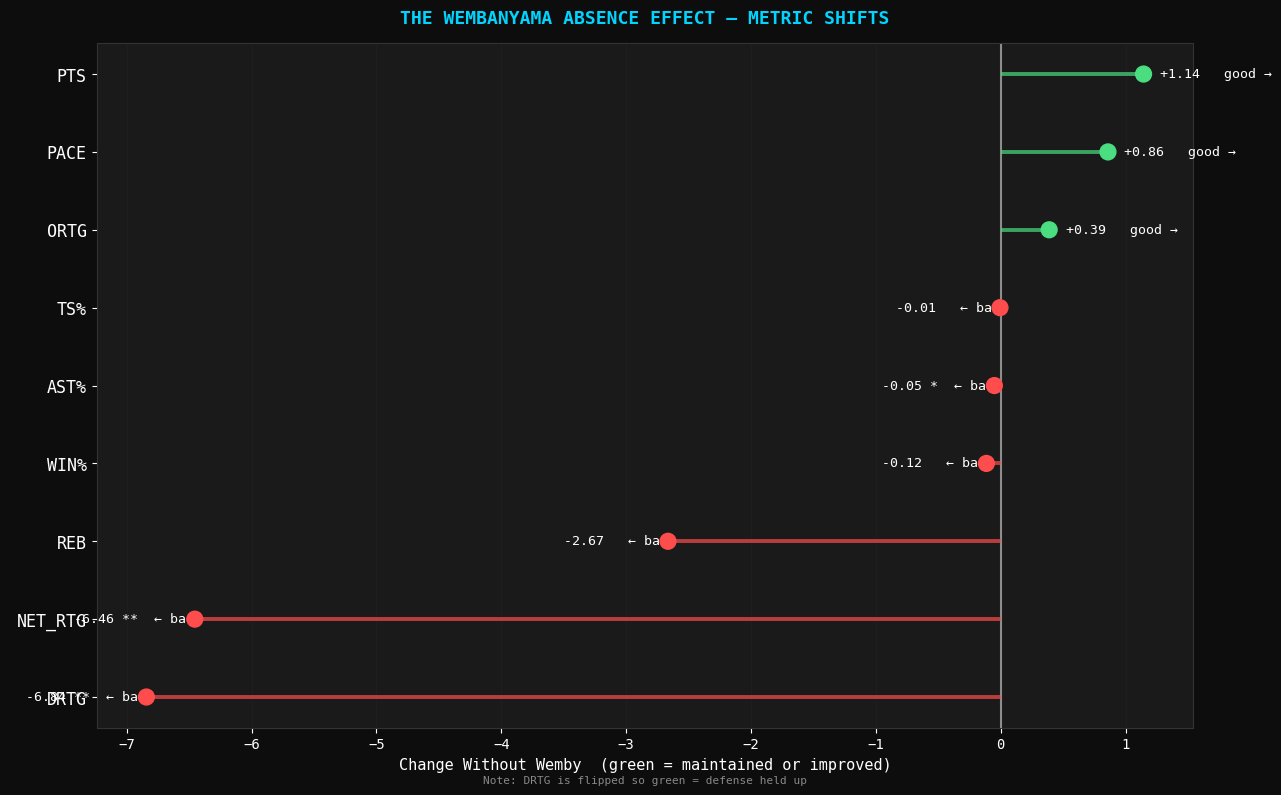

  Saved → fig_4_delta_lollipop.png
  Saved CSV → fig_5_ml_importance.csv


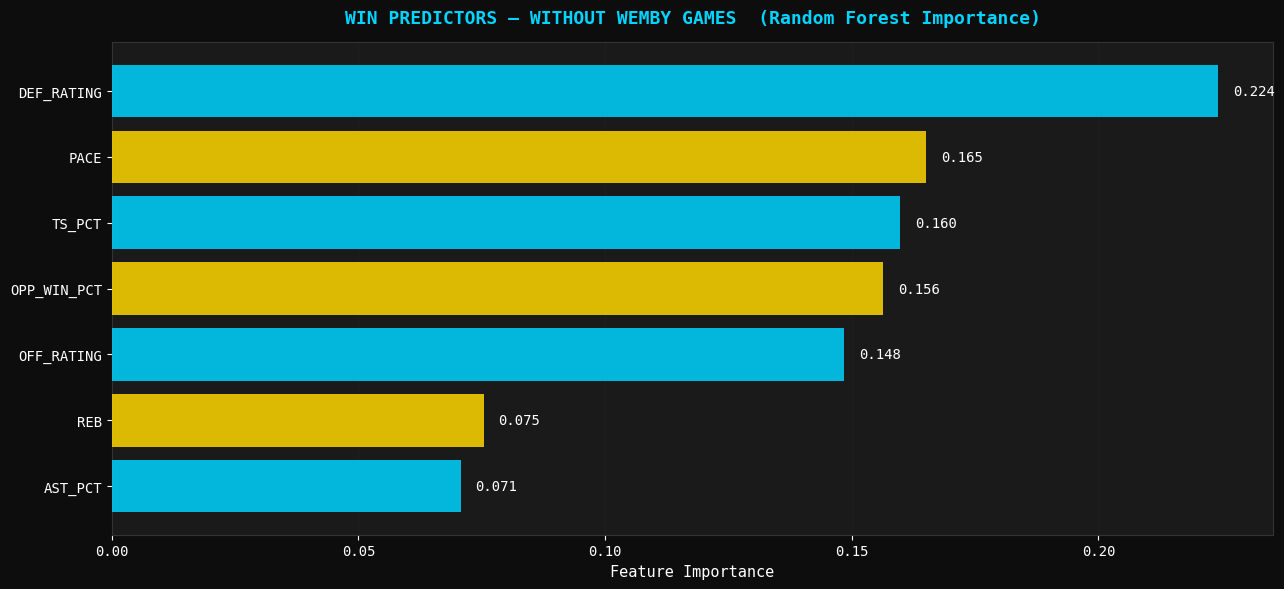

  Saved → fig_5_ml_importance.png
  Saved CSV → fig_6_trend_rolling.csv


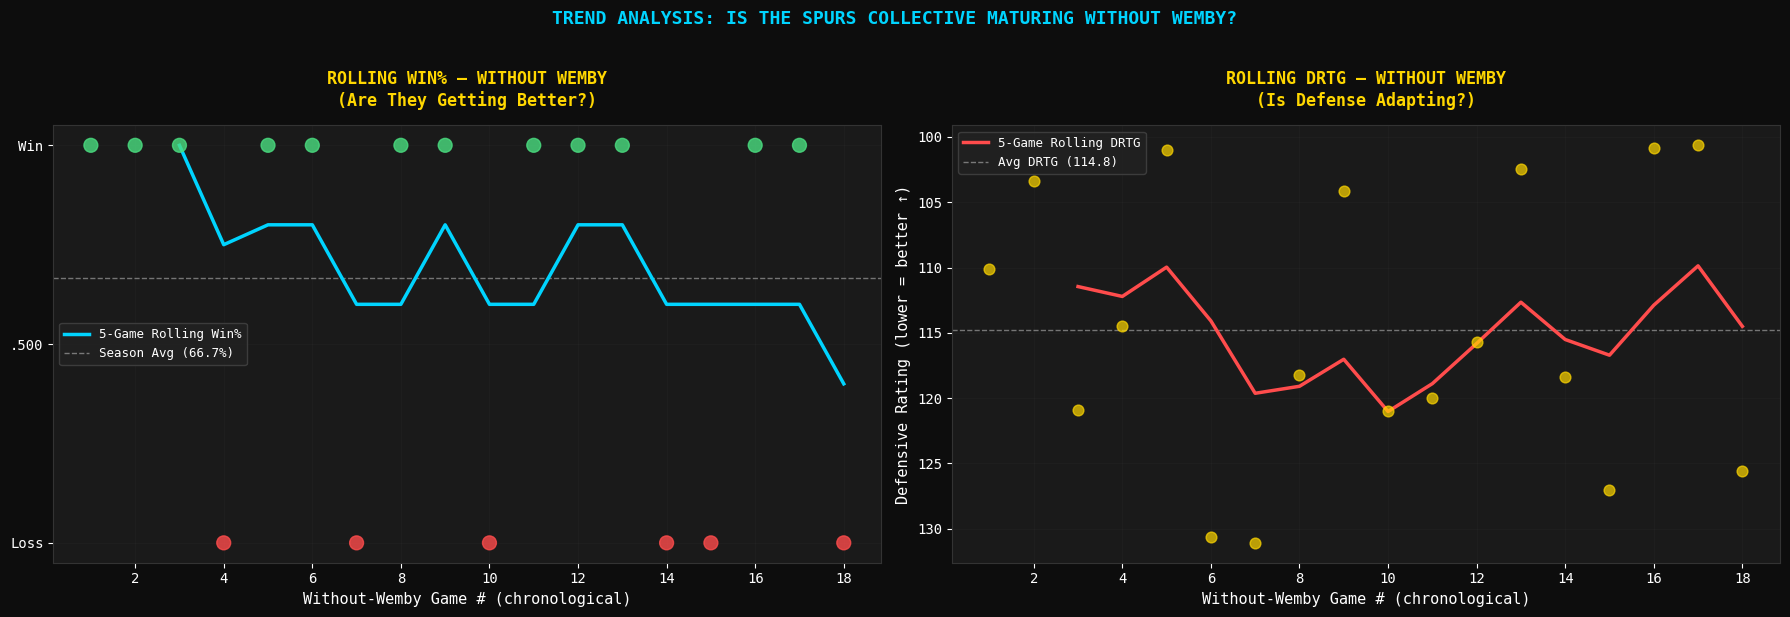

  Saved → fig_6_trend_rolling.png

  ALL DONE
  Outputs:
    - spurs_wemby_raw.csv
    - spurs_wemby_stats_summary.csv
    - 6 PNG files
    - 6 chart-ready CSV files for JavaScript animation


In [8]:
# ============================================================
# CELL 1 — Install dependencies
# ============================================================
# !pip install nba_api scikit-learn scipy


# ============================================================
# CELL 2 — SPURS WITH / WITHOUT WEMBANYAMA — FULL ANALYSIS PIPELINE
| 2025-26 Season
# Narrative goal: The Spurs are READY to play without Wemby
# ============================================================
#
# OUTPUTS:
#   spurs_wemby_raw.csv               — full game-level dataset
#   spurs_wemby_stats_summary.csv     — split summary table
#
#   fig_1_split_comparison.png
#   fig_1_split_comparison.csv
#
#   fig_2_drtg_timeline.png
#   fig_2_drtg_timeline.csv
#
#   fig_3_opp_quality_scatter.png
#   fig_3_opp_quality_scatter.csv
#
#   fig_4_delta_lollipop.png
#   fig_4_delta_lollipop.csv
#
#   fig_5_ml_importance.png
#   fig_5_ml_importance.csv
#
#   fig_6_trend_rolling.png
#   fig_6_trend_rolling.csv
#
# RUNTIME NOTE:
#   All advanced metrics derived from TeamGameLog — no per-game loop needed.
#   If you already have spurs_wemby_raw.csv, set SKIP_FETCH=True.
# ============================================================

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator
from scipy.stats import ttest_ind

warnings.filterwarnings("ignore")

from nba_api.stats.endpoints import (
    PlayerGameLog,
    TeamGameLog,
    LeagueDashTeamStats,
)
from nba_api.stats.static import teams as nba_teams_static

# ============================================================
# CONFIG
# ============================================================

SEASON          = "2025-26"
WEMBY_ID        = 1641705
SPURS_TEAM_ID   = 1610612759
SLEEP_BASE      = 3
SLEEP_MAX       = 15
SKIP_FETCH      = False
EXPORT_CHART_CSVS = True

OUTPUT_CSV      = "spurs_wemby_raw.csv"
SUMMARY_CSV     = "spurs_wemby_stats_summary.csv"

# ── Dark theme palette ────────────────────────────────────────
BG     = "#0d0d0d"
PANEL  = "#1a1a1a"
CYAN   = "#00d4ff"
GOLD   = "#FFD700"
RED    = "#FF4C4C"
GREEN  = "#4ADE80"
GRAY   = "#888888"
WHITE  = "#FFFFFF"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    "#333333",
    "text.color":        WHITE,
    "axes.labelcolor":   WHITE,
    "xtick.color":       WHITE,
    "ytick.color":       WHITE,
    "grid.color":        "#333333",
    "grid.alpha":        0.4,
    "font.family":       "monospace",
    "axes.titlepad":     14,
})

# ============================================================
# HELPERS
# ============================================================

def sleep_api(t=SLEEP_BASE):
    time.sleep(t)


def save_chart_csv(df: pd.DataFrame, filename: str):
    if not EXPORT_CHART_CSVS:
        return
    export_df = df.copy()
    for col in export_df.columns:
        if pd.api.types.is_datetime64_any_dtype(export_df[col]):
            export_df[col] = pd.to_datetime(export_df[col]).dt.strftime("%Y-%m-%d")
    export_df.to_csv(filename, index=False)
    print(f"  Saved CSV → {filename}")


def _save(name: str):
    plt.tight_layout()
    plt.savefig(name, dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print(f"  Saved → {name}")


def sig_stars(p: float) -> str:
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


def effect_label(d: float) -> str:
    if d < 0.2:
        return "Negligible"
    if d < 0.5:
        return "Small"
    if d < 0.8:
        return "Medium"
    return "Large"


# ============================================================
# SECTION 1 — DATA EXTRACTION
# ============================================================

# Build abbreviation → team_id lookup once at module level
# so it doesn't need to be recreated inside multiple functions.
_ALL_TEAMS    = pd.DataFrame(nba_teams_static.get_teams())
ABBR_TO_ID    = dict(zip(_ALL_TEAMS["abbreviation"], _ALL_TEAMS["id"]))


def fetch_wemby_game_ids() -> set:
    """Return set of Game_IDs where Wembanyama appeared."""
    print("  [1/4] Wembanyama game log...")
    gl = PlayerGameLog(
        player_id=WEMBY_ID,
        season=SEASON,
        season_type_all_star="Regular Season",
        timeout=60,
    )
    sleep_api()
    df = gl.get_data_frames()[0]
    ids = set(df["Game_ID"].astype(str).str.zfill(10))
    print(f"         → {len(ids)} games with Wemby")
    return ids


def fetch_spurs_game_log() -> pd.DataFrame:
    """Spurs full game log for the season."""
    print("  [2/4] Spurs team game log...")
    gl = TeamGameLog(
        team_id=SPURS_TEAM_ID,
        season=SEASON,
        season_type_all_star="Regular Season",
        timeout=60,
    )
    sleep_api()
    df = gl.get_data_frames()[0]
    df["GAME_ID"]   = df["Game_ID"].astype(str).str.zfill(10)
    df["WIN"]       = df["WL"] == "W"
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values("GAME_DATE").reset_index(drop=True)
    df["GAME_NUM"]  = range(1, len(df) + 1)
    print(f"         → {len(df)} total games")
    return df


def fetch_opponent_quality() -> pd.DataFrame:
    """
    Fetch season-level opponent quality.
    Base call gives W_PCT. Advanced call gives NET_RATING.
    """
    print("  [3/4] League team standings for opponent quality...")

    base = LeagueDashTeamStats(
        season=SEASON,
        season_type_all_star="Regular Season",
        per_mode_detailed="PerGame",
        timeout=60,
    )
    sleep_api()
    base_df = base.get_data_frames()[0]

    adv = LeagueDashTeamStats(
        season=SEASON,
        season_type_all_star="Regular Season",
        per_mode_detailed="PerGame",
        measure_type_detailed_defense="Advanced",
        timeout=60,
    )
    sleep_api()
    adv_df = adv.get_data_frames()[0]

    base_cols = ["TEAM_ID", "TEAM_NAME", "W_PCT"]
    adv_cols  = ["TEAM_ID", "NET_RATING"] if "NET_RATING" in adv_df.columns else ["TEAM_ID"]

    merged = base_df[base_cols].merge(adv_df[adv_cols], on="TEAM_ID", how="left")

    if "NET_RATING" not in merged.columns:
        print("         ⚠ NET_RATING unavailable — using W_PCT-based proxy")
        merged["NET_RATING"] = (merged["W_PCT"] - 0.5) * 20

    print(f"         → {len(merged)} teams, columns: {list(merged.columns)}")
    return merged.copy()


def fetch_opp_pts(spurs_log: pd.DataFrame) -> pd.Series:
    """
    Fetch opponent points by matching each Spurs game against the
    opponent's TeamGameLog. Returns Series indexed in Spurs log order.
    """
    spurs_log   = spurs_log.copy()
    unique_opps = spurs_log["OPP_ABBR"].unique()

    print(f"  [4/4] Fetching {len(unique_opps)} opponent game logs for OPP_PTS...")

    opp_pts_map = {}
    sleep_t     = SLEEP_BASE

    for abbr in unique_opps:
        team_id = ABBR_TO_ID.get(abbr)
        if team_id is None:
            print(f"         ⚠ Unknown abbreviation: {abbr} — skipping")
            continue

        try:
            gl = TeamGameLog(
                team_id=team_id,
                season=SEASON,
                season_type_all_star="Regular Season",
                timeout=60,
            )
            time.sleep(sleep_t)
            opp_df = gl.get_data_frames()[0]
            opp_df["Game_ID_pad"] = opp_df["Game_ID"].astype(str).str.zfill(10)

            for _, row in opp_df.iterrows():
                opp_pts_map[row["Game_ID_pad"]] = int(row["PTS"])

            sleep_t = SLEEP_BASE
            print(f"         ✓ {abbr}  ({len(opp_df)} games)")

        except Exception as e:
            sleep_t = min(sleep_t + 3, SLEEP_MAX)
            print(f"         ⚠ {abbr} error — {e}")
            time.sleep(sleep_t)

    result  = spurs_log["GAME_ID"].map(opp_pts_map)
    missing = result.isna().sum()
    if missing:
        print(f"         ⚠ {missing} games missing OPP_PTS after lookup")
    print(f"         → OPP_PTS resolved for {result.notna().sum()} / {len(result)} games")
    return result


def derive_advanced(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive advanced metrics from team game log columns.
    """
    df = df.copy()

    df["S_POSS"] = (df["FGA"] - df["OREB"] + df["TOV"] + 0.44 * df["FTA"]).clip(lower=1.0)

    df["OFF_RATING"] = (100.0 * df["PTS"] / df["S_POSS"]).round(2)

    # NOTE: uses the team's own possession estimate as the denominator
    # (a standard approximation when opponent possessions are unavailable).
    # Discrepancy vs. official NBA DRTG is typically < 2 pts/100 possessions.
    df["DEF_RATING"] = (
        (100.0 * df["OPP_PTS"] / df["S_POSS"])
        .where(df["OPP_PTS"].notna(), other=np.nan)
        .round(2)
    )

    df["NET_RATING"] = (df["OFF_RATING"] - df["DEF_RATING"]).round(2)

    # NOTE: MIN from TeamGameLog is total player-minutes (~240 for regulation).
    # Dividing by 5 converts to game-minutes (~48), giving possessions per 48 min.
    # For regulation games this is numerically equivalent to raw team possessions.
    df["PACE"] = (48.0 * df["S_POSS"] / (df["MIN"] / 5.0)).round(2)

    ts_denom    = 2.0 * (df["FGA"] + 0.44 * df["FTA"])
    df["TS_PCT"] = (df["PTS"] / ts_denom).where(ts_denom > 0, 0.0).round(4)

    df["AST_PCT"] = (df["AST"] / df["FGM"]).where(df["FGM"] > 0, 0.0).round(4)

    return df


def build_dataset() -> pd.DataFrame:
    """Build or reload the full dataset."""
    if SKIP_FETCH and os.path.exists(OUTPUT_CSV):
        print(f"  SKIP_FETCH=True — loading {OUTPUT_CSV}")
        return pd.read_csv(OUTPUT_CSV, parse_dates=["GAME_DATE"])

    print("\n[STEP 1] Fetching data...\n")

    wemby_ids   = fetch_wemby_game_ids()
    spurs_log   = fetch_spurs_game_log()
    opp_quality = fetch_opponent_quality()

    spurs_log["WITH_WEMBY"] = spurs_log["GAME_ID"].isin(wemby_ids)
    # WIN already set in fetch_spurs_game_log(); no reassignment needed here.

    spurs_log["OPP_ABBR"] = spurs_log["MATCHUP"].str.split().str[-1]
    spurs_log["OPP_ID"]   = spurs_log["OPP_ABBR"].map(ABBR_TO_ID)

    opp_q = opp_quality.set_index("TEAM_ID")
    spurs_log["OPP_WIN_PCT"]    = spurs_log["OPP_ID"].map(opp_q["W_PCT"])
    spurs_log["OPP_NET_RATING"] = spurs_log["OPP_ID"].map(opp_q["NET_RATING"])

    spurs_log["OPP_PTS"] = fetch_opp_pts(spurs_log)
    df = derive_advanced(spurs_log)

    df.to_csv(OUTPUT_CSV, index=False)
    print(f"\n  Saved → {OUTPUT_CSV}  ({len(df)} games)")
    return df


# ============================================================
# SECTION 2 — STATISTICAL ANALYSIS
# ============================================================

METRIC_CONFIG = {
    "WIN%":    ("WIN_FLOAT", False),
    "ORTG":    ("OFF_RATING", False),
    "DRTG":    ("DEF_RATING", True),
    "NET_RTG": ("NET_RATING", False),
    "PACE":    ("PACE", False),
    "TS%":     ("TS_PCT", False),
    "REB":     ("REB", False),
    "AST%":    ("AST_PCT", False),
    "PTS":     ("PTS", False),
}


def compute_splits(df: pd.DataFrame):
    df = df.copy()
    df["WIN_FLOAT"] = df["WIN"].astype(float)

    with_df    = df[df["WITH_WEMBY"]].copy()
    without_df = df[~df["WITH_WEMBY"]].copy()

    print(f"\n{'='*65}")
    print("  GAME SPLIT SUMMARY")
    print(f"{'='*65}")
    print(f"  With Wemby   : {len(with_df)} games   W-L: {with_df['WIN'].sum()}-{(~with_df['WIN']).sum()} ({with_df['WIN'].mean():.1%})")
    print(f"  Without Wemby: {len(without_df)} games   W-L: {without_df['WIN'].sum()}-{(~without_df['WIN']).sum()} ({without_df['WIN'].mean():.1%})")
    print(f"{'='*65}")
    print(f"  {'Metric':<12} {'With':>8} {'W/O':>8} {'Delta':>8} {'p-val':>8} {'Cohen d':>9} {'Effect':<12} Sig")
    print(f"  {'-'*75}")

    rows = []

    for label, (col, lower_better) in METRIC_CONFIG.items():
        if col not in df.columns:
            continue

        w  = with_df[col].dropna()
        wo = without_df[col].dropna()

        if len(w) < 3 or len(wo) < 3:
            continue

        w_mean  = w.mean()
        wo_mean = wo.mean()
        delta   = wo_mean - w_mean

        _, p     = ttest_ind(w, wo, equal_var=False)
        pool_sd  = np.sqrt((w.std()**2 + wo.std()**2) / 2)
        cohd     = abs(delta) / pool_sd if pool_sd > 0 else 0
        sig      = sig_stars(p)
        fx       = effect_label(cohd)

        narr_delta = -delta if lower_better else delta

        print(f"  {label:<12} {w_mean:>8.2f} {wo_mean:>8.2f} {delta:>+8.2f} {p:>8.4f} {cohd:>9.3f} {fx:<12} {sig}")

        rows.append({
            "Metric":        label,
            "Col":           col,
            "Lower_Better":  lower_better,
            "With_Wemby":    round(w_mean, 3),
            "Without_Wemby": round(wo_mean, 3),
            "Delta":         round(delta, 3),
            "Narr_Delta":    round(narr_delta, 3),
            "p_value":       round(p, 4),
            "Cohens_d":      round(cohd, 3),
            "Effect":        fx,
            "Sig":           sig,
        })

    stats_df = pd.DataFrame(rows)
    return stats_df, with_df, without_df


def analyze_opponent_quality(with_df: pd.DataFrame, without_df: pd.DataFrame):
    print(f"\n{'='*65}")
    print("  OPPONENT QUALITY ANALYSIS  (Are the without-Wemby games soft?)")
    print(f"{'='*65}")

    w_opp  = with_df["OPP_WIN_PCT"].dropna()
    wo_opp = without_df["OPP_WIN_PCT"].dropna()
    _, p   = ttest_ind(w_opp, wo_opp, equal_var=False)

    print(f"  Avg Opponent Win%  — WITH Wemby   : {w_opp.mean():.3f}")
    print(f"  Avg Opponent Win%  — WITHOUT Wemby: {wo_opp.mean():.3f}  Δ={wo_opp.mean()-w_opp.mean():+.3f}  p={p:.3f}")

    for threshold, label in [(0.5, "above .500"), (0.6, "elite (≥60% win)")]:
        a_w  = with_df[with_df["OPP_WIN_PCT"] >= threshold]
        a_wo = without_df[without_df["OPP_WIN_PCT"] >= threshold]
        b_w  = with_df[with_df["OPP_WIN_PCT"] < threshold]
        b_wo = without_df[without_df["OPP_WIN_PCT"] < threshold]

        print(f"\n  vs {label} opponents:")
        print(f"    WITH Wemby   : {a_w['WIN'].mean():.1%} ({a_w['WIN'].sum()}-{(~a_w['WIN']).sum()})  [{len(a_w)} games]")
        print(f"    WITHOUT Wemby: {a_wo['WIN'].mean():.1%} ({a_wo['WIN'].sum()}-{(~a_wo['WIN']).sum()})  [{len(a_wo)} games]")
        print(f"  vs below {threshold:.0%} opponents:")
        print(f"    WITH Wemby   : {b_w['WIN'].mean():.1%} ({b_w['WIN'].sum()}-{(~b_w['WIN']).sum()})  [{len(b_w)} games]")
        print(f"    WITHOUT Wemby: {b_wo['WIN'].mean():.1%} ({b_wo['WIN'].sum()}-{(~b_wo['WIN']).sum()})  [{len(b_wo)} games]")


def analyze_trend(df: pd.DataFrame):
    print(f"\n{'='*65}")
    print("  TREND ANALYSIS: Getting better WITHOUT Wemby over time?")
    print(f"{'='*65}")

    wo = df[~df["WITH_WEMBY"]].copy().sort_values("GAME_NUM").reset_index(drop=True)
    if len(wo) < 6:
        print("  Insufficient without-Wemby games for trend analysis.")
        return

    mid   = len(wo) // 2
    early = wo.iloc[:mid]
    late  = wo.iloc[mid:]

    for metric, col in [("Win%", "WIN"), ("DRTG", "DEF_RATING"), ("ORTG", "OFF_RATING")]:
        e_val     = early[col].astype(float).mean()
        l_val     = late[col].astype(float).mean()
        direction = "▲" if l_val > e_val else "▼"
        if metric == "DRTG":
            direction = "▲ (better)" if l_val < e_val else "▼ (worse)"
        print(f"  {metric:<8}: Early {e_val:.2f}  →  Late {l_val:.2f}  {direction}")


# ============================================================
# SECTION 3 — MACHINE LEARNING
# ============================================================

def run_ml_analysis(df: pd.DataFrame):
    """
    Logistic regression + Random Forest on WITHOUT-Wemby games only.
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import cross_val_score, StratifiedKFold

    print(f"\n{'='*65}")
    print("  ML ANALYSIS — WIN PREDICTORS IN WITHOUT-WEMBY GAMES")
    print(f"{'='*65}")

    candidate_cols = [
        "OFF_RATING", "DEF_RATING", "PACE",
        "TS_PCT", "REB", "AST_PCT", "OPP_WIN_PCT"
    ]
    feature_cols = [c for c in candidate_cols if c in df.columns]

    wo_clean = df[~df["WITH_WEMBY"]][feature_cols + ["WIN"]].dropna()

    if len(wo_clean) < 8:
        print("  ⚠ Not enough games for ML — skipping.")
        return None

    X = wo_clean[feature_cols].values
    y = wo_clean["WIN"].astype(int).values

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    n_splits = min(5, len(wo_clean) // 3)
    if n_splits < 2:
        print("  ⚠ Not enough games for cross-validation — skipping.")
        return None

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, C=0.5),
        "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42, max_depth=4),
        "Gradient Boost":      GradientBoostingClassifier(n_estimators=100, random_state=42),
    }

    rf_model = None

    for name, model in models.items():
        scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="accuracy")
        model.fit(X_scaled, y)
        print(f"  {name:<24}: CV Accuracy {scores.mean():.3f} ± {scores.std():.3f}")
        if name == "Random Forest":
            rf_model = model

    imp_df = pd.DataFrame({
        "Feature":       feature_cols,
        "RF_Importance": rf_model.feature_importances_,
    }).sort_values("RF_Importance", ascending=False)

    print("\n  Feature Importance (Random Forest):")
    for _, row in imp_df.iterrows():
        bar = "█" * int(row["RF_Importance"] * 60)
        print(f"    {row['Feature']:<15} {bar} {row['RF_Importance']:.3f}")

    return imp_df


# ============================================================
# SECTION 4 — VISUALIZATIONS + CSV EXPORTS
# ============================================================

def plot_split_comparison(stats_df: pd.DataFrame):
    # ── Split metrics by scale so neither group becomes invisible ──
    # Rating-scale metrics (ORTG, DRTG, PACE) live on one y-axis (~90–120).
    # Proportion-scale metrics (WIN%, NET_RTG, TS%) live on a second panel.
    rating_metrics = ["ORTG", "DRTG", "PACE"]
    prop_metrics   = ["WIN%", "NET_RTG", "TS%"]

    df_rating = stats_df[stats_df["Metric"].isin(rating_metrics)].copy()
    df_prop   = stats_df[stats_df["Metric"].isin(prop_metrics)].copy()

    export_df = stats_df[stats_df["Metric"].isin(rating_metrics + prop_metrics)][[
        "Metric", "With_Wemby", "Without_Wemby",
        "Delta", "Narr_Delta", "p_value",
        "Cohens_d", "Effect", "Sig"
    ]].copy()
    save_chart_csv(export_df, "fig_1_split_comparison.csv")

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    w = 0.36

    def _draw_panel(ax, df, title_suffix):
        x     = np.arange(len(df))
        bars1 = ax.bar(x - w/2, df["With_Wemby"],    w, color=CYAN, alpha=0.85, zorder=3, label="With Wemby")
        bars2 = ax.bar(x + w/2, df["Without_Wemby"], w, color=GOLD, alpha=0.85, zorder=3, label="Without Wemby")

        # Significance markers above the taller bar
        for i, (_, row) in enumerate(df.iterrows()):
            if row["Sig"]:
                y_top = max(row["With_Wemby"], row["Without_Wemby"])
                y_off = y_top * 0.03 if y_top > 1 else 0.02
                ax.text(i, y_top + y_off, row["Sig"],
                        ha="center", va="bottom", color=RED, fontsize=14, fontweight="bold")

        # Value labels — offset relative to each bar's own scale
        for bar in bars1:
            h   = bar.get_height()
            off = h * 0.015 if h > 1 else 0.008
            ax.text(bar.get_x() + bar.get_width() / 2, h + off,
                    f"{h:.2f}", ha="center", va="bottom", color=CYAN, fontsize=8.5)

        for bar in bars2:
            h   = bar.get_height()
            off = h * 0.015 if h > 1 else 0.008
            ax.text(bar.get_x() + bar.get_width() / 2, h + off,
                    f"{h:.2f}", ha="center", va="bottom", color=GOLD, fontsize=8.5)

        ax.set_xticks(x)
        ax.set_xticklabels(df["Metric"], fontsize=12)
        ax.set_title(f"SPURS: WITH vs. WITHOUT WEMBANYAMA\n{title_suffix}",
                     fontsize=12, color=CYAN, fontweight="bold")
        ax.legend(facecolor="#222", edgecolor="#444", labelcolor=WHITE, fontsize=10)
        ax.grid(axis="y", alpha=0.25, zorder=0)
        ax.text(0.01, 0.01, "* p<0.1  ** p<0.05  *** p<0.01",
                transform=ax.transAxes, color=GRAY, fontsize=8)

    _draw_panel(axes[0], df_rating, "Rating Metrics")
    _draw_panel(axes[1], df_prop,   "Proportion Metrics")

    _save("fig_1_split_comparison.png")


def plot_drtg_timeline(df: pd.DataFrame):
    df = df.sort_values("GAME_NUM").copy()
    df["DRTG_ROLL5"] = df["DEF_RATING"].rolling(window=5, center=True, min_periods=3).mean()

    export_df = df[[
        "GAME_ID", "GAME_DATE", "GAME_NUM", "MATCHUP", "WL",
        "WITH_WEMBY", "WIN", "DEF_RATING", "DRTG_ROLL5",
        "OFF_RATING", "NET_RATING", "OPP_ABBR", "OPP_WIN_PCT", "OPP_NET_RATING"
    ]].copy()
    save_chart_csv(export_df, "fig_2_drtg_timeline.csv")

    fig, ax = plt.subplots(figsize=(18, 6))

    for _, row in df[~df["WITH_WEMBY"]].iterrows():
        ax.axvspan(row["GAME_NUM"] - 0.5, row["GAME_NUM"] + 0.5,
                   alpha=0.18, color=GOLD, zorder=1)

    with_df    = df[df["WITH_WEMBY"]]
    without_df = df[~df["WITH_WEMBY"]]

    ax.scatter(with_df["GAME_NUM"],    with_df["DEF_RATING"],    color=CYAN, s=45,  zorder=5, alpha=0.8, label="With Wemby")
    ax.scatter(without_df["GAME_NUM"], without_df["DEF_RATING"], color=GOLD, s=65,  zorder=6, alpha=0.9, marker="D", label="Without Wemby")
    ax.plot(df["GAME_NUM"], df["DRTG_ROLL5"], color=RED, linewidth=2.2, alpha=0.75, zorder=4, label="5-Game Rolling Avg")

    season_avg = df["DEF_RATING"].mean()
    ax.axhline(season_avg, color=WHITE, linewidth=1, linestyle="--",
               alpha=0.3, label=f"Season Avg ({season_avg:.1f})")

    ax.invert_yaxis()
    ax.set_xlabel("Game Number (Chronological)", fontsize=11)
    ax.set_ylabel("Defensive Rating  (lower = better ↑)", fontsize=11)
    ax.set_title("DEFENSIVE RATING TIMELINE  ·  GOLD SHADING = WEMBY ABSENT",
                 fontsize=13, color=CYAN, fontweight="bold")
    ax.legend(facecolor="#222", edgecolor="#444", labelcolor=WHITE, fontsize=9)
    ax.grid(alpha=0.2, zorder=0)

    wo_drtg = without_df["DEF_RATING"].mean()
    w_drtg  = with_df["DEF_RATING"].mean()
    ax.text(
        0.98, 0.05,
        f"DRTG WITH: {w_drtg:.1f}\nDRTG W/O:  {wo_drtg:.1f}  (Δ={wo_drtg-w_drtg:+.1f})",
        transform=ax.transAxes, ha="right", va="bottom", color=WHITE, fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#222", edgecolor="#555")
    )

    _save("fig_2_drtg_timeline.png")


def plot_opp_quality_scatter(with_df: pd.DataFrame, without_df: pd.DataFrame):
    export_with              = with_df[["GAME_ID", "GAME_DATE", "GAME_NUM", "MATCHUP", "WL",
                                         "WITH_WEMBY", "WIN", "OPP_ABBR", "OPP_WIN_PCT",
                                         "OPP_NET_RATING", "NET_RATING", "OFF_RATING", "DEF_RATING"]].copy()
    export_with["SPLIT"]     = "With Wemby"
    export_without           = without_df[["GAME_ID", "GAME_DATE", "GAME_NUM", "MATCHUP", "WL",
                                            "WITH_WEMBY", "WIN", "OPP_ABBR", "OPP_WIN_PCT",
                                            "OPP_NET_RATING", "NET_RATING", "OFF_RATING", "DEF_RATING"]].copy()
    export_without["SPLIT"]  = "Without Wemby"

    export_df = pd.concat([export_with, export_without], ignore_index=True)
    save_chart_csv(export_df, "fig_3_opp_quality_scatter.csv")

    fig, axes = plt.subplots(1, 2, figsize=(17, 7), sharey=True)

    for ax, title, d, header_color in zip(
        axes,
        ["WITH WEMBY", "WITHOUT WEMBY"],
        [with_df, without_df],
        [CYAN, GOLD]
    ):
        wins   = d[d["WIN"]]
        losses = d[~d["WIN"]]

        ax.scatter(wins["OPP_WIN_PCT"],   wins["NET_RATING"],   color=GREEN, s=90, zorder=5, alpha=0.85, marker="o", label="WIN")
        ax.scatter(losses["OPP_WIN_PCT"], losses["NET_RATING"], color=RED,   s=90, zorder=5, alpha=0.85, marker="X", label="LOSS")

        ax.axvline(0.5, color=WHITE, linewidth=1, linestyle="--", alpha=0.3)
        ax.axhline(0,   color=WHITE, linewidth=1, linestyle="--", alpha=0.3)

        win_pct = d["WIN"].mean()
        ax.set_title(
            f"{title}\n{win_pct:.1%}  ({int(d['WIN'].sum())}-{len(d)-int(d['WIN'].sum())})",
            color=header_color, fontsize=12, fontweight="bold"
        )
        ax.set_xlabel("Opponent Win%", fontsize=11)
        if ax == axes[0]:
            ax.set_ylabel("Spurs Game Net Rating", fontsize=11)

        ax.legend(facecolor="#222", edgecolor="#444", labelcolor=WHITE, fontsize=10)
        ax.grid(alpha=0.2, zorder=0)
        ax.text(0.26, 0.04, "BEAT GOOD TEAMS →", transform=ax.transAxes, color=GRAY, fontsize=7.5)

    fig.suptitle("WIN/LOSS vs OPPONENT QUALITY", fontsize=14,
                 color=CYAN, fontweight="bold", y=1.02)
    _save("fig_3_opp_quality_scatter.png")


def plot_delta_lollipop(stats_df: pd.DataFrame):
    df = stats_df.copy().sort_values("Narr_Delta")

    export_df = df[[
        "Metric", "With_Wemby", "Without_Wemby",
        "Delta", "Narr_Delta", "Lower_Better",
        "p_value", "Cohens_d", "Effect", "Sig"
    ]].copy()
    save_chart_csv(export_df, "fig_4_delta_lollipop.csv")

    fig, ax = plt.subplots(figsize=(13, 8))
    colors  = [GREEN if v >= 0 else RED for v in df["Narr_Delta"]]

    ax.hlines(range(len(df)), 0, df["Narr_Delta"], colors=colors, linewidth=2.8, alpha=0.7, zorder=3)
    ax.scatter(df["Narr_Delta"], range(len(df)), color=colors, s=130, zorder=5)

    for i, (_, row) in enumerate(df.iterrows()):
        offset = 0.003 if row["Narr_Delta"] >= 0 else -0.003
        ha     = "left" if row["Narr_Delta"] >= 0 else "right"
        note   = "← bad" if row["Narr_Delta"] < 0 else "good →" if row["Narr_Delta"] > 0.01 else ""
        ax.text(
            row["Narr_Delta"] + offset, i,
            f"  {row['Narr_Delta']:+.2f} {row['Sig']}  {note}",
            va="center", ha=ha, color=WHITE, fontsize=9.5
        )

    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df["Metric"], fontsize=12)
    ax.axvline(0, color=WHITE, linewidth=1.5, alpha=0.5)
    ax.set_xlabel("Change Without Wemby  (green = maintained or improved)", fontsize=11)
    ax.set_title("THE WEMBANYAMA ABSENCE EFFECT — METRIC SHIFTS",
                 fontsize=13, color=CYAN, fontweight="bold")
    ax.grid(axis="x", alpha=0.2, zorder=0)
    ax.text(0.5, -0.08, "Note: DRTG is flipped so green = defense held up",
            transform=ax.transAxes, ha="center", color=GRAY, fontsize=8)

    _save("fig_4_delta_lollipop.png")


def plot_ml_importance(imp_df: pd.DataFrame):
    if imp_df is None:
        print("  Skipping Fig 5 (insufficient data).")
        return

    export_df = imp_df.copy().sort_values("RF_Importance", ascending=False)
    save_chart_csv(export_df, "fig_5_ml_importance.csv")

    imp_df = imp_df.sort_values("RF_Importance")
    fig, ax = plt.subplots(figsize=(13, 6))

    colors = [CYAN if i % 2 == 0 else GOLD for i in range(len(imp_df))]
    bars   = ax.barh(imp_df["Feature"], imp_df["RF_Importance"], color=colors, alpha=0.85, zorder=3)

    for bar, val in zip(bars, imp_df["RF_Importance"]):
        ax.text(
            bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va="center", ha="left", color=WHITE, fontsize=10
        )

    ax.set_title("WIN PREDICTORS — WITHOUT WEMBY GAMES  (Random Forest Importance)",
                 fontsize=13, color=CYAN, fontweight="bold")
    ax.set_xlabel("Feature Importance", fontsize=11)
    ax.grid(axis="x", alpha=0.2, zorder=0)

    _save("fig_5_ml_importance.png")


def plot_trend_rolling(df: pd.DataFrame):
    wo = df[~df["WITH_WEMBY"]].copy().sort_values("GAME_NUM").reset_index(drop=True)
    wo["GAME_SEQ"] = range(1, len(wo) + 1)
    wo["WIN_ROLL"]  = wo["WIN"].astype(float).rolling(window=5, min_periods=3).mean()
    wo["DRTG_ROLL"] = wo["DEF_RATING"].rolling(window=5, min_periods=3).mean()

    if len(wo) < 6:
        print("  Skipping Fig 6 (insufficient without-Wemby games).")
        return

    export_df = wo[[
        "GAME_ID", "GAME_DATE", "GAME_NUM", "GAME_SEQ", "MATCHUP", "WL",
        "WIN", "WITH_WEMBY", "DEF_RATING", "DRTG_ROLL",
        "OFF_RATING", "NET_RATING", "WIN_ROLL",
        "OPP_ABBR", "OPP_WIN_PCT", "OPP_NET_RATING"
    ]].copy()
    save_chart_csv(export_df, "fig_6_trend_rolling.csv")

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Panel A — Rolling Win%
    ax = axes[0]
    scatter_colors = [GREEN if w else RED for w in wo["WIN"]]
    ax.scatter(wo["GAME_SEQ"], wo["WIN"].astype(int), c=scatter_colors, s=100, zorder=5, alpha=0.8)
    ax.plot(wo["GAME_SEQ"], wo["WIN_ROLL"],
            color=CYAN, linewidth=2.5, zorder=4, label="5-Game Rolling Win%")
    ax.axhline(wo["WIN"].mean(), color=WHITE, linewidth=1, linestyle="--",
               alpha=0.4, label=f"Season Avg ({wo['WIN'].mean():.1%})")
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["Loss", ".500", "Win"])
    ax.set_xlabel("Without-Wemby Game # (chronological)", fontsize=11)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_title("ROLLING WIN% — WITHOUT WEMBY\n(Are They Getting Better?)",
                 color=GOLD, fontsize=12, fontweight="bold")
    ax.legend(facecolor="#222", edgecolor="#444", labelcolor=WHITE, fontsize=9)
    ax.grid(alpha=0.2, zorder=0)

    # Panel B — Rolling DRTG
    ax2 = axes[1]
    ax2.scatter(wo["GAME_SEQ"], wo["DEF_RATING"], color=GOLD, s=60, zorder=5, alpha=0.7)
    ax2.plot(wo["GAME_SEQ"], wo["DRTG_ROLL"],
             color=RED, linewidth=2.5, zorder=4, label="5-Game Rolling DRTG")
    ax2.axhline(wo["DEF_RATING"].mean(), color=WHITE, linewidth=1, linestyle="--",
                alpha=0.4, label=f"Avg DRTG ({wo['DEF_RATING'].mean():.1f})")
    ax2.invert_yaxis()
    ax2.set_xlabel("Without-Wemby Game # (chronological)", fontsize=11)
    ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2.set_ylabel("Defensive Rating (lower = better ↑)", fontsize=11)
    ax2.set_title("ROLLING DRTG — WITHOUT WEMBY\n(Is Defense Adapting?)",
                  color=GOLD, fontsize=12, fontweight="bold")
    ax2.legend(facecolor="#222", edgecolor="#444", labelcolor=WHITE, fontsize=9)
    ax2.grid(alpha=0.2, zorder=0)

    fig.suptitle("TREND ANALYSIS: IS THE SPURS COLLECTIVE MATURING WITHOUT WEMBY?",
                 fontsize=13, color=CYAN, fontweight="bold", y=1.02)
    _save("fig_6_trend_rolling.png")


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    print("\n" + "="*65)
    print("  SPURS WITH / WITHOUT WEMBANYAMA — FULL ANALYSIS")
    print(f"  Season: {SEASON}")
    print("="*65)

    # 1. Build dataset
    df = build_dataset()
    print(f"\n  Dataset shape: {df.shape}")
    print(f"  With Wemby: {df['WITH_WEMBY'].sum()} | Without: {(~df['WITH_WEMBY']).sum()}")

    # 2. Statistical splits
    print("\n[STEP 2] Statistical Analysis\n")
    stats_df, with_df, without_df = compute_splits(df)

    # 3. Opponent quality
    print("\n[STEP 3] Opponent Quality\n")
    analyze_opponent_quality(with_df, without_df)

    # 4. Trend analysis
    print("\n[STEP 4] Trend Analysis\n")
    analyze_trend(df)

    # 5. ML
    print("\n[STEP 5] Machine Learning\n")
    imp_df = run_ml_analysis(df)

    # 6. Save summary CSV
    stats_df.to_csv(SUMMARY_CSV, index=False)
    print(f"\n  Saved → {SUMMARY_CSV}")

    # 7. Visualizations + chart CSVs
    print("\n[STEP 6] Generating Visualizations + CSV Exports\n")
    plot_split_comparison(stats_df)
    plot_drtg_timeline(df)
    plot_opp_quality_scatter(with_df, without_df)
    plot_delta_lollipop(stats_df)
    plot_ml_importance(imp_df)
    plot_trend_rolling(df)

    print("\n" + "="*65)
    print("  ALL DONE")
    print("  Outputs:")
    print("    - spurs_wemby_raw.csv")
    print("    - spurs_wemby_stats_summary.csv")
    print("    - 6 PNG files")
    print("    - 6 chart-ready CSV files for JavaScript animation")
    print("="*65)